# 📊 Notebook 10 — Comparativa Cross-Compression

Este notebook unifica los resultados de evaluación de los 4 modelos (**XceptionNet, EfficientNet-B3, MesoInception-4, ViT**) sobre los tres niveles de compresión del dataset FaceForensics++:

| Dataset | Compresión | Calidad |
|---------|------------|--------|
| C23 | Media (entrenamiento) | Alta |
| C40 | Alta compresión | Baja |
| C0  | Sin compresión (raw) | Máxima |

**Hipótesis esperada:** Los modelos deberían rendir mejor en C0 (más detalle visible) y peor en C40 (compresión oculta artefactos de deepfake). El C23 es el dominio de entrenamiento.

---

## 📦 1. Importaciones y Configuración

In [1]:
import os
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import time
import warnings
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from tqdm import tqdm
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, log_loss, roc_auc_score,
    matthews_corrcoef, confusion_matrix, roc_curve
)
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import timm

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'🔥 Dispositivo: {DEVICE}')

🔥 Dispositivo: cuda


## ⚙️ 2. Rutas

In [2]:
# ============================================================
#  RUTAS DE DATASETS
# ============================================================
# C23: usa CSV (split 'test') igual que en el Notebook 05
CSV_C23 = r'C:\TFG\Dataset_Final_Procesado\registro_datos.csv'

# C40 y C0: estructura de carpetas real/fake
PATH_C40 = r'C:\TFG\Dataset_C40_Procesado\test'
PATH_C0  = r'C:\TFG\Dataset_C0_Procesado\test'

# ============================================================
#  RUTAS DE PESOS (mismos para los 3 datasets)
# ============================================================
MODEL_PATHS = {
    'XceptionNet':    r'C:\TFG\modelos\best_xception_loss.pth',
    'EfficientNet-B3': r'C:\TFG\modelos\best_effnet_loss.pth',
    'MesoInception-4': r'C:\TFG\modelos\best_mesoinception_mejorado_loss.pth',
    'ViT':            r'C:\TFG\modelos\best_vit_loss.pth',
}

MODELOS   = list(MODEL_PATHS.keys())
DATASETS  = ['C23', 'C40', 'C0']

## 🏗️ 3. Clases Dataset

In [3]:
# ── Dataset C23 (vía CSV, como en Notebook 05) ────────────────────────────────
class DeepfakeDatasetCSV(Dataset):
    def __init__(self, csv_path, split='test', transform=None):
        df = pd.read_csv(csv_path)
        self.df = df[df['split'] == split].reset_index(drop=True)
        self.transform = transform
        self.label_dict = {'real': 0, 'fake': 1}

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row['path']).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, self.label_dict[row['label']]


# ── Dataset C40 / C0 (vía carpetas real/fake) ────────────────────────────────
class DeepfakeDatasetFolder(Dataset):
    def __init__(self, root_dir, transform=None):
        self.transform = transform
        self.samples = []
        for label in ['real', 'fake']:
            folder = os.path.join(root_dir, label)
            if os.path.exists(folder):
                for img in os.listdir(folder):
                    if img.lower().endswith(('.jpg', '.jpeg', '.png')):
                        self.samples.append((os.path.join(folder, img), 0 if label == 'real' else 1))
        if not self.samples:
            raise RuntimeError(f'No se encontraron imágenes en {root_dir}')

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, label

## 🏛️ 4. Definición de Arquitecturas

In [4]:
class MesoInception4(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.inception1 = self._inception_layer(3, 8, 8, 8, 8)
        self.inception2 = self._inception_layer(32, 8, 16, 16, 8)
        self.conv3 = nn.Conv2d(48, 64, kernel_size=5, padding=2)
        self.relu = nn.ReLU()
        self.leaky_relu = nn.LeakyReLU(0.1)
        self.bn1 = nn.BatchNorm2d(64)
        self.maxpool1 = nn.MaxPool2d(2, 2)
        self.conv4 = nn.Conv2d(64, 64, kernel_size=5, padding=2)
        self.bn2 = nn.BatchNorm2d(64)
        self.maxpool2 = nn.MaxPool2d(4, 4)
        self.dropout = nn.Dropout(0.5)
        self.fc1 = nn.Linear(64 * 8 * 8, 256)
        self.fc2 = nn.Linear(256, num_classes)

    def _inception_layer(self, ic, o1, o2, o3, o4):
        return nn.ModuleList([
            nn.Sequential(nn.Conv2d(ic, o1, 1, padding=0), nn.BatchNorm2d(o1), nn.ReLU()),
            nn.Sequential(nn.Conv2d(ic, o2, 3, padding=1), nn.BatchNorm2d(o2), nn.ReLU()),
            nn.Sequential(nn.Conv2d(ic, o3, 5, padding=2), nn.BatchNorm2d(o3), nn.ReLU()),
            nn.Sequential(nn.Conv2d(ic, o4, 7, padding=3), nn.BatchNorm2d(o4), nn.ReLU()),
        ])

    def forward(self, x):
        x = torch.cat([l(x) for l in self.inception1], 1)
        x = nn.MaxPool2d(2, 2)(x)
        x = torch.cat([l(x) for l in self.inception2], 1)
        x = nn.MaxPool2d(2, 2)(x)
        x = self.relu(self.bn1(self.conv3(x)))
        x = self.maxpool1(x)
        x = self.relu(self.bn2(self.conv4(x)))
        x = self.maxpool2(x)
        x = x.view(x.size(0), -1)
        x = self.dropout(x)
        x = self.leaky_relu(self.fc1(x))
        x = self.dropout(x)
        return self.fc2(x)


def build_model(name):
    if name == 'XceptionNet':
        return timm.create_model('xception', pretrained=False, num_classes=2)
    elif name == 'EfficientNet-B3':
        return timm.create_model('tf_efficientnet_b3', pretrained=False, num_classes=2)
    elif name == 'MesoInception-4':
        return MesoInception4(num_classes=2)
    elif name == 'ViT':
        return timm.create_model('vit_base_patch16_224', pretrained=False, num_classes=2)
    else:
        raise ValueError(f'Modelo desconocido: {name}')


# Transformaciones por modelo (idénticas a los notebooks anteriores)
TRANSFORMS = {
    'XceptionNet':    transforms.Compose([transforms.Resize((299, 299)), transforms.ToTensor(),
                                           transforms.Normalize([0.5]*3, [0.5]*3)]),
    'EfficientNet-B3': transforms.Compose([transforms.Resize((300, 300)), transforms.ToTensor(),
                                            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])]),
    'MesoInception-4': transforms.Compose([transforms.Resize((256, 256)), transforms.ToTensor(),
                                            transforms.Normalize([0.5]*3, [0.5]*3)]),
    'ViT':            transforms.Compose([transforms.Resize((224, 224)), transforms.ToTensor(),
                                           transforms.Normalize([0.5]*3, [0.5]*3)]),
}

## 🔧 5. Funciones Auxiliares

In [5]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad) / 1e6


def run_inference(model, loader, model_name):
    model.eval().to(DEVICE)
    y_true, y_prob = [], []
    t0 = time.time()
    with torch.no_grad():
        for inputs, labels in tqdm(loader, desc=f'  → {model_name}', leave=False):
            inputs = inputs.to(DEVICE)
            out = model(inputs)
            probs = torch.softmax(out, dim=1)[:, 1].cpu().numpy()
            y_prob.extend(probs)
            y_true.extend(labels.numpy())
    time_ms = ((time.time() - t0) / len(y_true)) * 1000
    return np.array(y_true), np.array(y_prob), time_ms


def compute_metrics(name, dataset, y_true, y_prob, time_ms, params_m):
    y_pred = (y_prob >= 0.5).astype(int)
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    fnr = 1 - tpr
    eer = fpr[np.nanargmin(np.abs(fnr - fpr))]

    return {
        'Modelo':   name,
        'Dataset':  dataset,
        'Acc':      accuracy_score(y_true, y_pred),
        'Prec':     precision_score(y_true, y_pred, zero_division=0),
        'Rec':      recall_score(y_true, y_pred, zero_division=0),
        'F1':       f1_score(y_true, y_pred, zero_division=0),
        'Spec':     tn / (tn + fp) if (tn + fp) else 0,
        'MCC':      matthews_corrcoef(y_true, y_pred),
        'AUC':      roc_auc_score(y_true, y_prob),
        'Loss':     log_loss(y_true, y_prob, labels=[0, 1]),
        'EER':      eer,
        'FPR@0.5':  fp / (fp + tn) if (fp + tn) else 0,
        'Time_ms':  time_ms,
        'Params_M': params_m,
        '_cm':      cm,
        '_fpr':     fpr,
        '_tpr':     tpr,
        '_y_true':  y_true,
        '_y_prob':  y_prob,
    }

## 🚀 6. Bucle Principal de Evaluación Cross-Compression

> Cada modelo se carga **una sola vez** y se evalúa en los 3 datasets.

In [7]:
all_results = []   # lista de dicts con métricas
roc_data    = {}   # {(modelo, dataset): (fpr, tpr, auc)}
cm_data     = {}   # {(modelo, dataset): confusion_matrix}

SEP = '=' * 60
for nombre, path in MODEL_PATHS.items():
    print(f'\n{SEP}')
    print(f'🏛️  Modelo: {nombre}')
    print(SEP)

    try:
        model = build_model(nombre)
        model.load_state_dict(torch.load(path, map_location=DEVICE))
        params_m = count_parameters(model)
        tf = TRANSFORMS[nombre]

        for ds_name, ds_source in [
            ('C23', ('csv',    CSV_C23)),
            ('C40', ('folder', PATH_C40)),
            ('C0',  ('folder', PATH_C0)),
        ]:
            print(f'  📂 Evaluando sobre {ds_name}...')
            kind, source = ds_source
            if kind == 'csv':
                dataset = DeepfakeDatasetCSV(source, split='test', transform=tf)
            else:
                dataset = DeepfakeDatasetFolder(source, transform=tf)

            loader = DataLoader(dataset, batch_size=32, shuffle=False, num_workers=0)
            y_true, y_prob, t_ms = run_inference(model, loader, nombre)
            metrics = compute_metrics(nombre, ds_name, y_true, y_prob, t_ms, params_m)
            all_results.append(metrics)
            roc_data[(nombre, ds_name)] = (metrics['_fpr'], metrics['_tpr'], metrics['AUC'])
            cm_data[(nombre, ds_name)]  = metrics['_cm']
            print(f'     ✅ Acc={metrics["Acc"]:.4f}  AUC={metrics["AUC"]:.4f}  F1={metrics["F1"]:.4f}')

    except Exception as e:
        print(f'  ❌ Error con {nombre}: {e}')

print('\n✅ Evaluación completa.')


🏛️  Modelo: XceptionNet
  📂 Evaluando sobre C23...


     ✅ Acc=0.8453  AUC=0.9283  F1=0.8415
  📂 Evaluando sobre C40...


     ✅ Acc=0.5844  AUC=0.6209  F1=0.6016
  📂 Evaluando sobre C0...


     ✅ Acc=0.9490  AUC=0.9986  F1=0.9512

🏛️  Modelo: EfficientNet-B3
  📂 Evaluando sobre C23...


     ✅ Acc=0.8034  AUC=0.8951  F1=0.8147
  📂 Evaluando sobre C40...


...

     ✅ Acc=0.6093  AUC=0.6621  F1=0.6064
  📂 Evaluando sobre C0...


     ✅ Acc=0.7435  AUC=0.8388  F1=0.7144

🏛️  Modelo: ViT
  📂 Evaluando sobre C23...


     ✅ Acc=0.9083  AUC=0.9687  F1=0.9027
  📂 Evaluando sobre C40...


     ✅ Acc=0.6546  AUC=0.7080  F1=0.6376
  📂 Evaluando sobre C0...


     ✅ Acc=0.9883  AUC=0.9989  F1=0.9884

✅ Evaluación completa.


## 📋 7. Tabla Comparativa Global

In [8]:
# Columnas de display (excluimos las privadas _*)
COLS_METRICS = ['Modelo', 'Dataset', 'Acc', 'Prec', 'Rec', 'F1', 'Spec', 'MCC', 'AUC', 'Loss', 'EER', 'FPR@0.5', 'Time_ms', 'Params_M']

df_all = pd.DataFrame(all_results)[COLS_METRICS].copy()

# Paletas
cm_green = sns.light_palette('seagreen', as_cmap=True)
cm_red   = sns.light_palette('indianred', as_cmap=True)

df_display = df_all.set_index(['Modelo', 'Dataset'])

display(
    df_display.style
    .background_gradient(cmap=cm_green, subset=['Acc', 'Prec', 'Rec', 'F1', 'Spec', 'MCC', 'AUC'])
    .background_gradient(cmap=cm_red,   subset=['Loss', 'EER', 'FPR@0.5', 'Time_ms'])
    .format({
        'Acc': '{:.4f}', 'Prec': '{:.4f}', 'Rec': '{:.4f}', 'F1': '{:.4f}',
        'Spec': '{:.4f}', 'MCC': '{:.4f}', 'AUC': '{:.4f}',
        'Loss': '{:.4f}', 'EER': '{:.4f}', 'FPR@0.5': '{:.4f}',
        'Time_ms': '{:.2f}', 'Params_M': '{:.2f}M'
    })
    .set_caption('Comparativa Cross-Compression — 4 modelos × 3 datasets')
)

In [9]:
# Exportar a CSV para el TFG
df_all.to_csv('Resultados_Cross_Compression.csv', index=False)
print('💾 Guardado: Resultados_Cross_Compression.csv')

💾 Guardado: Resultados_Cross_Compression.csv


## 📊 8. Gráfico de Barras — Métricas Clave por Dataset

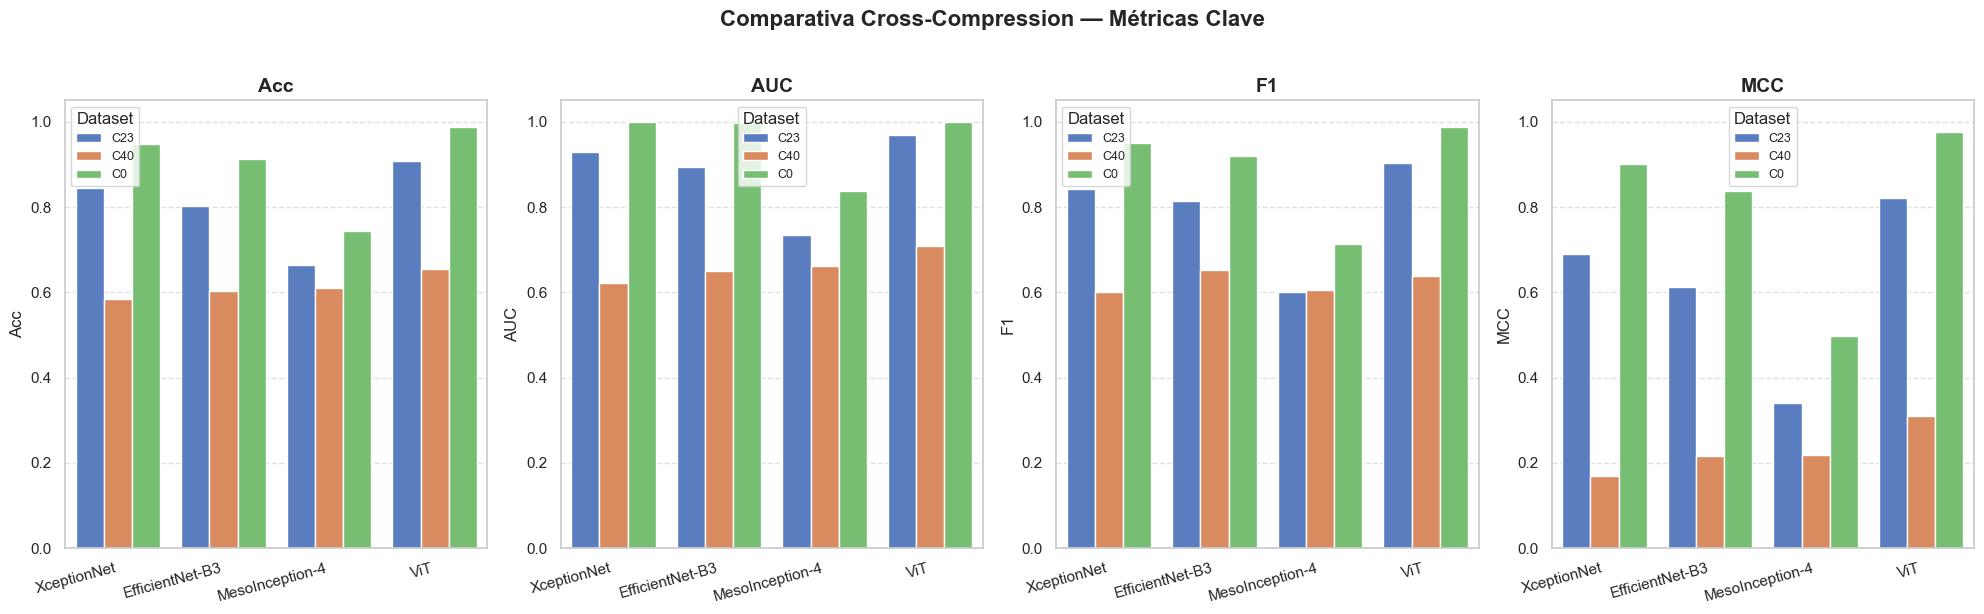

In [10]:
metricas_plot = ['Acc', 'AUC', 'F1', 'MCC']
fig, axes = plt.subplots(1, len(metricas_plot), figsize=(20, 6))

palette_ds = {'C23': '#4878d0', 'C40': '#ee854a', 'C0': '#6acc65'}

for ax, met in zip(axes, metricas_plot):
    sns.barplot(
        data=df_all, x='Modelo', y=met, hue='Dataset',
        palette=palette_ds, ax=ax, edgecolor='white'
    )
    ax.set_title(met, fontsize=14, fontweight='bold')
    ax.set_ylim(0, 1.05)
    ax.set_xlabel('')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha='right')
    ax.grid(axis='y', linestyle='--', alpha=0.6)
    ax.legend(title='Dataset', fontsize=9)

plt.suptitle('Comparativa Cross-Compression — Métricas Clave', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('comparativa_barras.png', dpi=150, bbox_inches='tight')
plt.show()

## 📉 9. Degradación por Compresión — Líneas por Modelo

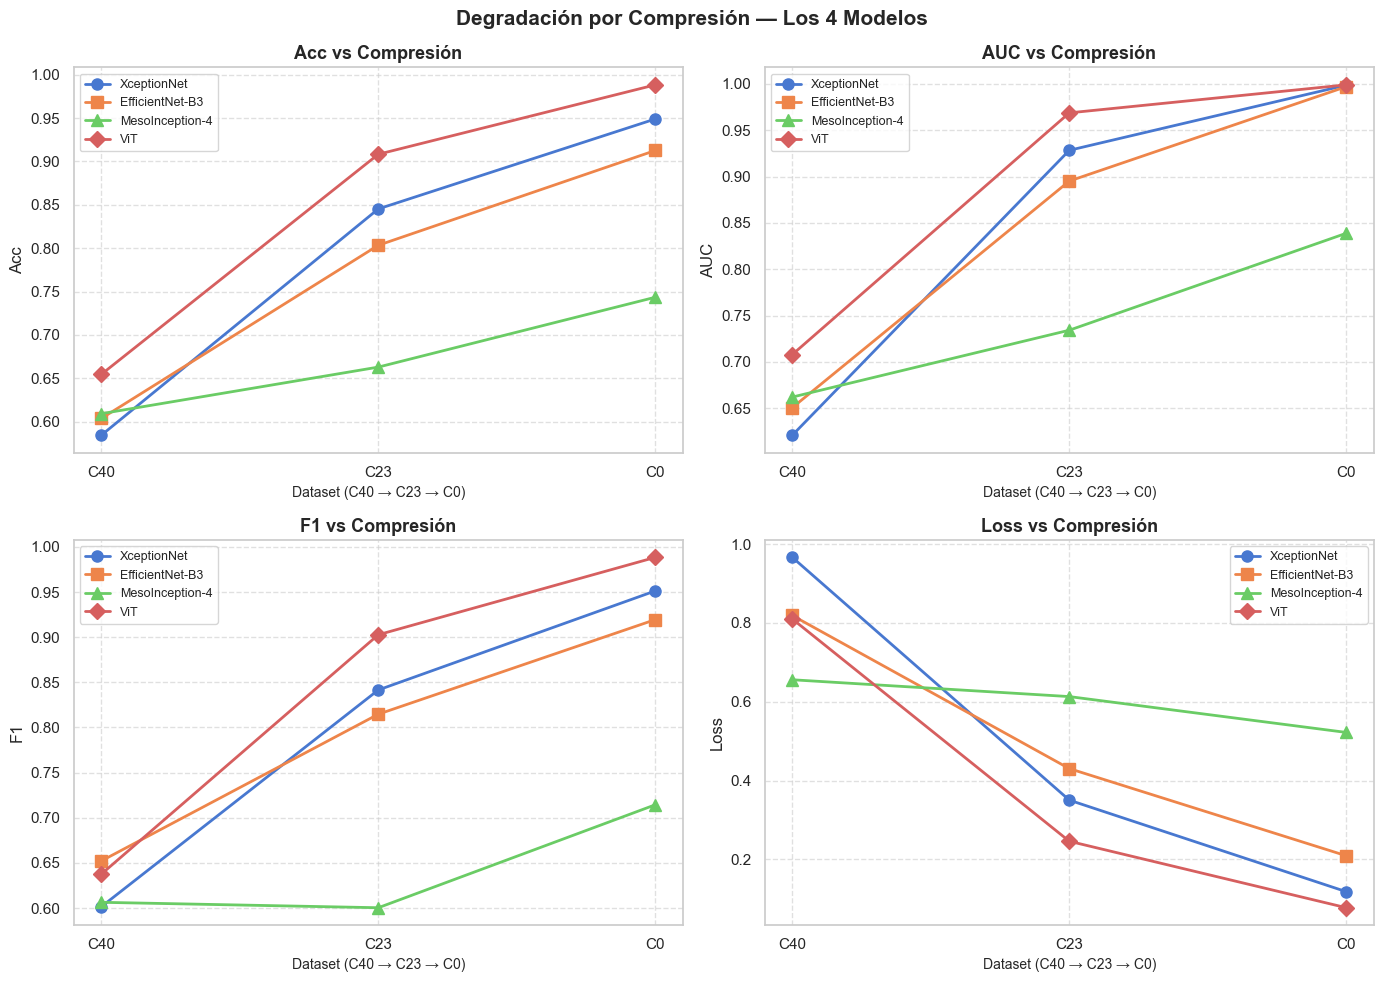

In [11]:
# Orden lógico de calidad creciente: C40 < C23 < C0
ORDEN_DS = ['C40', 'C23', 'C0']
df_line = df_all.copy()
df_line['Dataset'] = pd.Categorical(df_line['Dataset'], categories=ORDEN_DS, ordered=True)
df_line = df_line.sort_values('Dataset')

metricas_line = ['Acc', 'AUC', 'F1', 'Loss']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

colors_model = {
    'XceptionNet':    '#4878d0',
    'EfficientNet-B3': '#ee854a',
    'MesoInception-4': '#6acc65',
    'ViT':            '#d65f5f',
}
markers = {'XceptionNet': 'o', 'EfficientNet-B3': 's', 'MesoInception-4': '^', 'ViT': 'D'}

for ax, met in zip(axes, metricas_line):
    for modelo in MODELOS:
        sub = df_line[df_line['Modelo'] == modelo]
        ax.plot(
            sub['Dataset'].astype(str), sub[met],
            marker=markers[modelo], label=modelo,
            color=colors_model[modelo], linewidth=2, markersize=8
        )
    ax.set_title(f'{met} vs Compresión', fontsize=13, fontweight='bold')
    ax.set_xlabel('Dataset (C40 → C23 → C0)', fontsize=10)
    ax.set_ylabel(met)
    ax.legend(fontsize=9)
    ax.grid(linestyle='--', alpha=0.6)

plt.suptitle('Degradación por Compresión — Los 4 Modelos', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('comparativa_lineas.png', dpi=150, bbox_inches='tight')
plt.show()

## 🔵 10. Curvas ROC — Grilla 4 Modelos × 3 Datasets

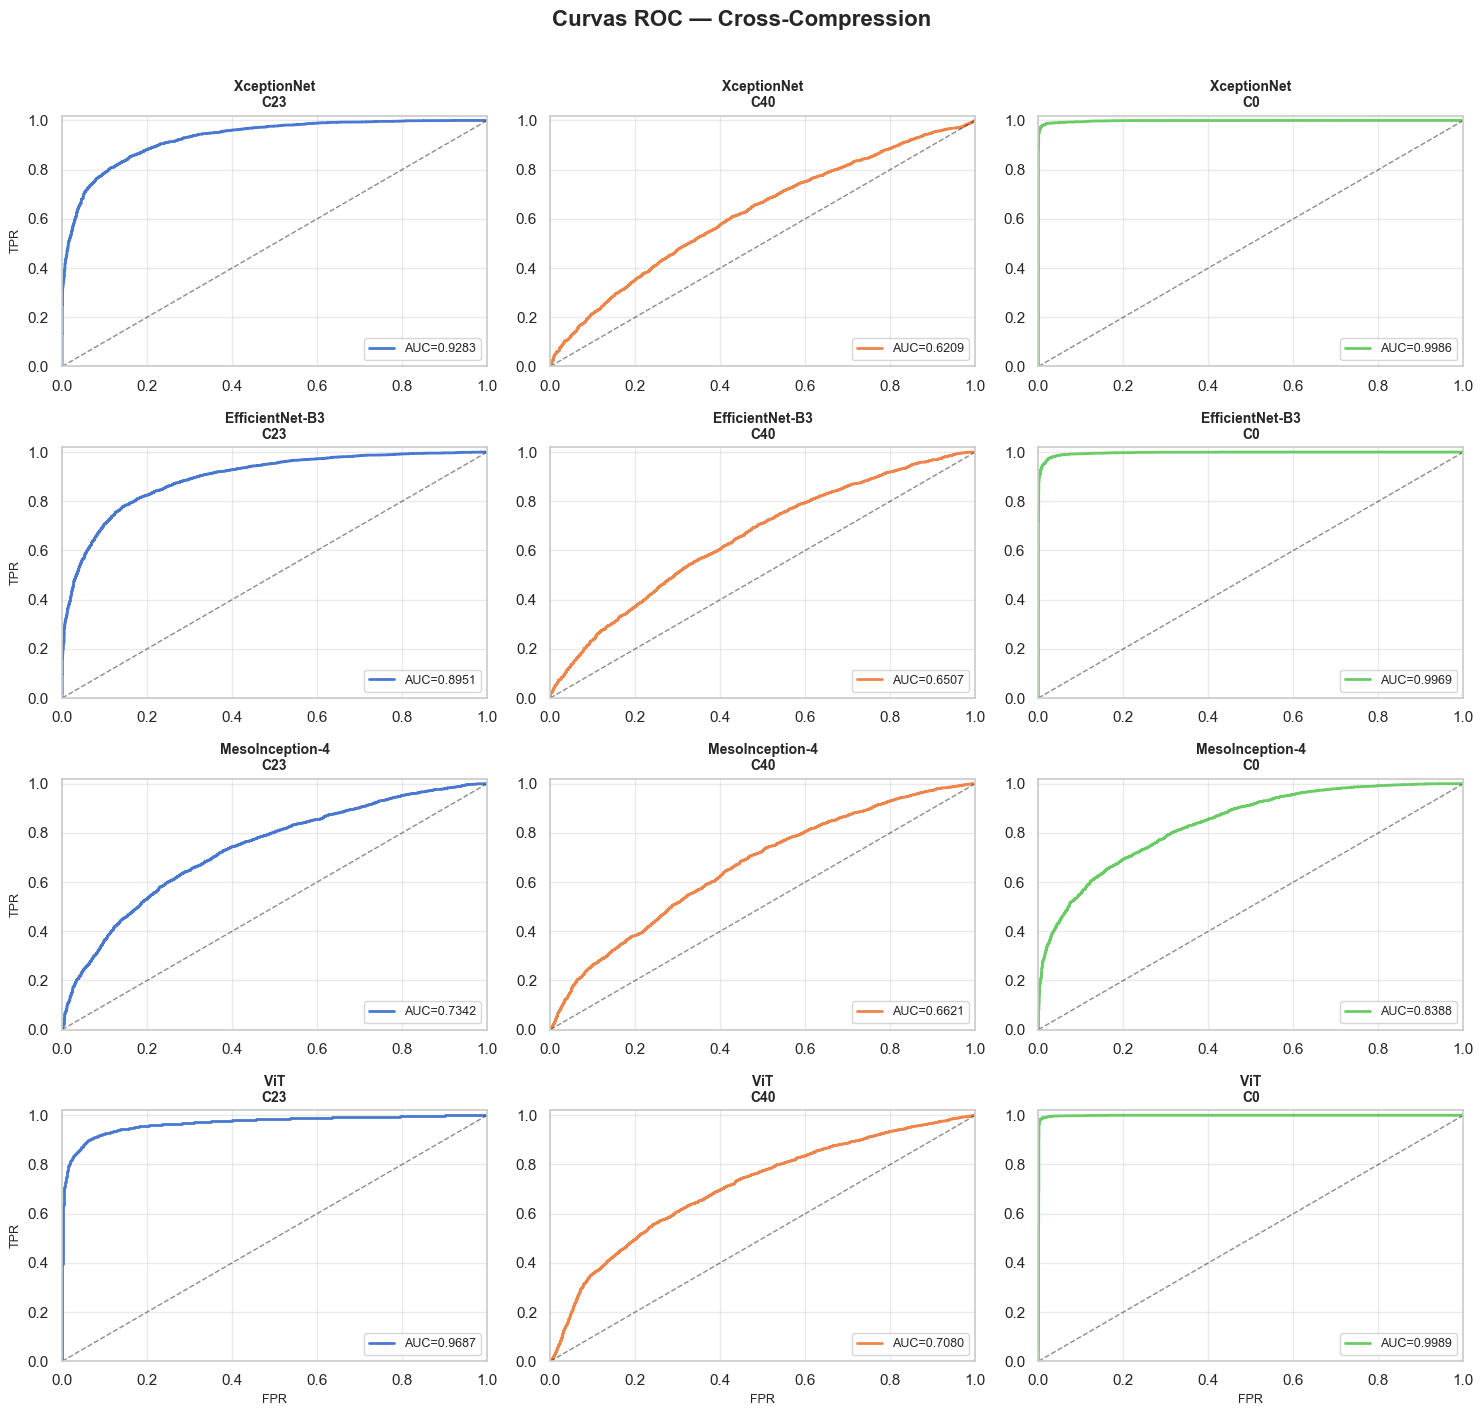

In [12]:
fig, axes = plt.subplots(len(MODELOS), len(DATASETS), figsize=(15, 14))
palette_ds_roc = {'C23': '#4878d0', 'C40': '#ee854a', 'C0': '#6acc65'}

for i, modelo in enumerate(MODELOS):
    for j, ds in enumerate(DATASETS):
        ax = axes[i][j]
        key = (modelo, ds)
        if key in roc_data:
            fpr, tpr, auc_val = roc_data[key]
            ax.plot(fpr, tpr, color=palette_ds_roc[ds], lw=2, label=f'AUC={auc_val:.4f}')
        ax.plot([0,1],[0,1], 'k--', lw=1, alpha=0.5)
        ax.set_xlim([0,1]); ax.set_ylim([0,1.02])
        ax.set_xlabel('FPR', fontsize=9) if i == len(MODELOS)-1 else None
        ax.set_ylabel('TPR', fontsize=9) if j == 0 else None
        ax.set_title(f'{modelo}\n{ds}', fontsize=10, fontweight='bold')
        ax.legend(loc='lower right', fontsize=9)
        ax.grid(alpha=0.4)

plt.suptitle('Curvas ROC — Cross-Compression', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('roc_cross_compression.png', dpi=150, bbox_inches='tight')
plt.show()

## 🔲 11. Matrices de Confusión — Grilla 4 Modelos × 3 Datasets

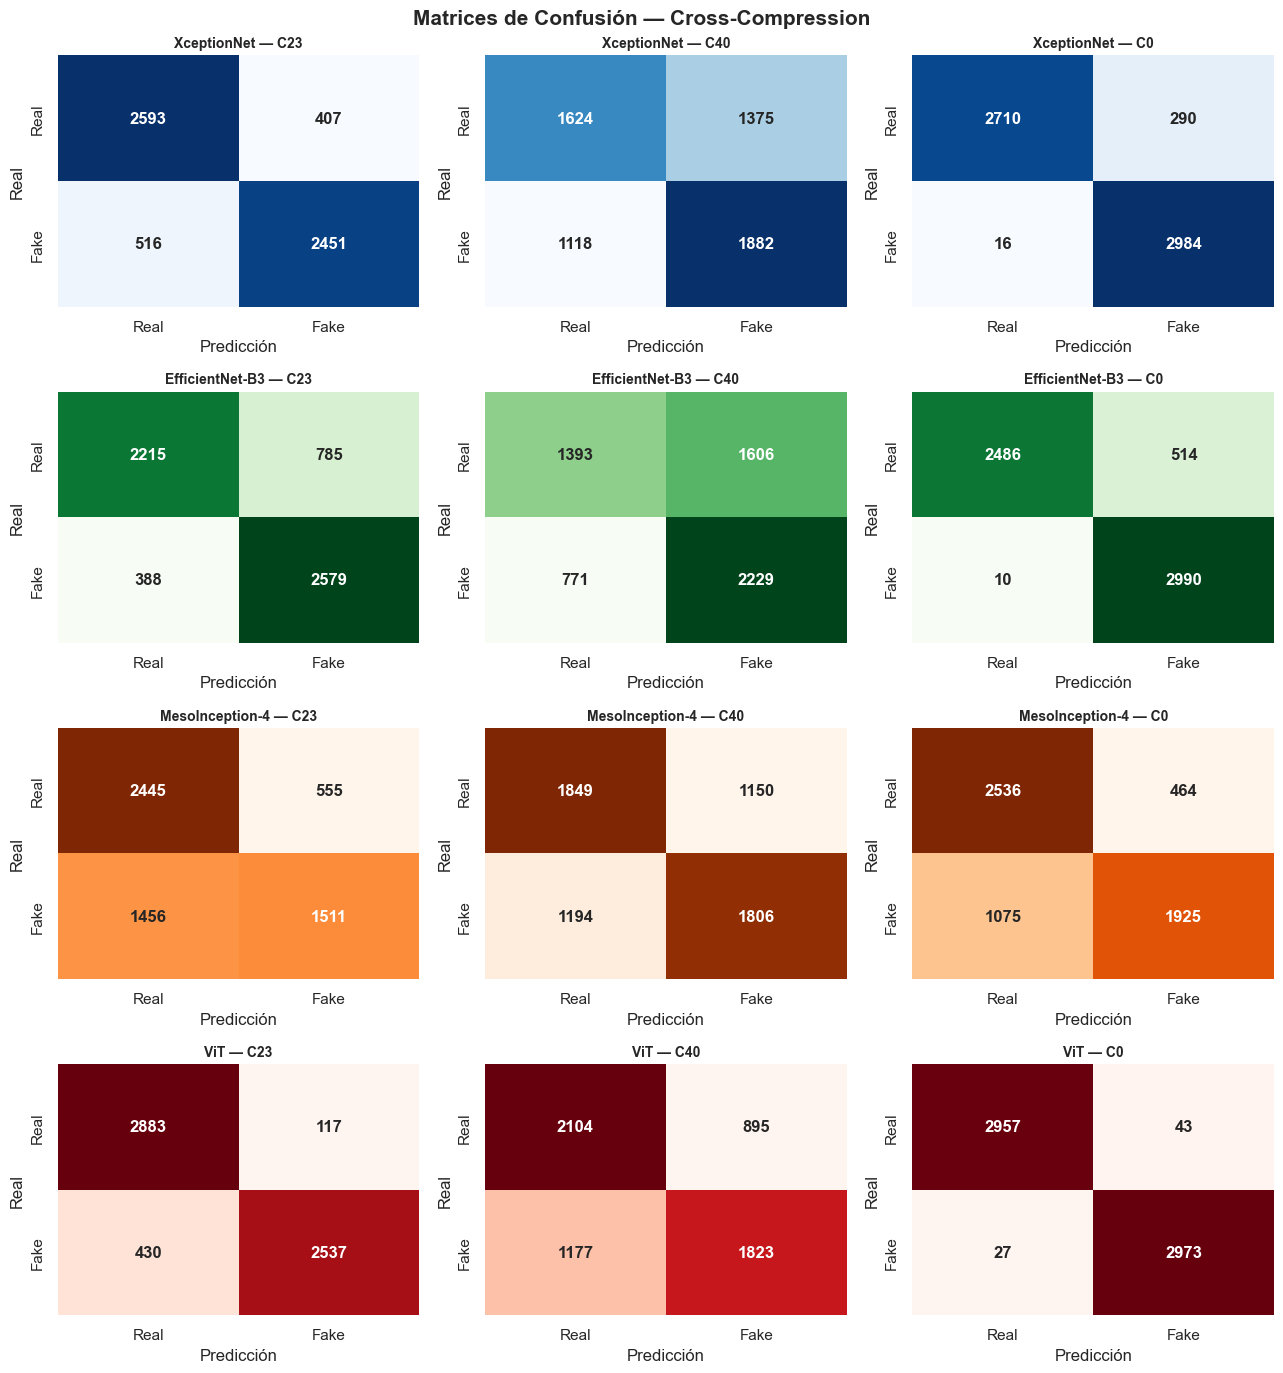

In [13]:
fig, axes = plt.subplots(len(MODELOS), len(DATASETS), figsize=(13, 14))
cmaps_model = ['Blues', 'Greens', 'Oranges', 'Reds']

for i, modelo in enumerate(MODELOS):
    for j, ds in enumerate(DATASETS):
        ax = axes[i][j]
        key = (modelo, ds)
        if key in cm_data:
            cm = cm_data[key]
            sns.heatmap(
                cm, annot=True, fmt='d', ax=ax,
                cmap=cmaps_model[i], cbar=False,
                annot_kws={'size': 12, 'weight': 'bold'}
            )
        ax.set_title(f'{modelo} — {ds}', fontsize=10, fontweight='bold')
        ax.set_xlabel('Predicción')
        ax.set_ylabel('Real')
        ax.set_xticklabels(['Real', 'Fake'])
        ax.set_yticklabels(['Real', 'Fake'])

plt.suptitle('Matrices de Confusión — Cross-Compression', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

## 📉 13. Resumen de Degradación (Δ respecto a C23)

In [16]:
# Calculamos la diferencia de cada métrica respecto al resultado en C23
metricas_delta = ['Acc', 'F1', 'AUC', 'MCC']
delta_records = []

for modelo in MODELOS:
    df_m = df_all[df_all['Modelo'] == modelo].set_index('Dataset')
    if 'C23' not in df_m.index:
        continue
    for ds in ['C40', 'C0']:
        if ds not in df_m.index:
            continue
        row = {'Modelo': modelo, 'vs C23 →': ds}
        for met in metricas_delta:
            row[f'Δ {met}'] = df_m.loc[ds, met] - df_m.loc['C23', met]
        delta_records.append(row)

df_delta = pd.DataFrame(delta_records).set_index(['Modelo', 'vs C23 →'])

display(
    df_delta.style
    .background_gradient(cmap='RdYlGn', axis=None)
    .format('{:+.4f}')
    .set_caption('Δ respecto a C23 — valores positivos = mejora, negativos = degradación')
)
print('\n🔵 C0 debería dar Δ positivo (más calidad → más detectable).'
      '\n🔴 C40 debería dar Δ negativo (menos calidad → más difícil).')


🔵 C0 debería dar Δ positivo (más calidad → más detectable).
🔴 C40 debería dar Δ negativo (menos calidad → más difícil).
